# Safer walking routes with quantum-inspired tensor networks

This notebook loads the saved Wits walking map, scores mapped street conditions, and searches a compact corridor using a **matrix product state (MPS)**. It runs on an ordinary computer. The Streamlit interface in `app.py` uses the same solver.

**Run from the Hackathon folder:** activate `.venv`, install the extra package with `uv pip install quimb`, and run this notebook. The saved `wits_walk_10km.graphml` must be in this folder.


## 1. The problem and the score

Each walking street has a cost. The current prototype uses distance, confirmed unlit lighting, unknown lighting, explicitly absent sidewalk, unknown sidewalk, and a major-road traffic proxy. Lower is preferred. The weights are in `route_core.edge_score`, measured per 100 m: distance **1**, unlit **3**, unknown lighting **1.5**, absent sidewalk **3**, unknown sidewalk **1**, major road **2**. An explicitly unmarked crossing adds **4**. These are prototype preferences, not measured GBV or crime risk.

A user can set the maximum **continuous confirmed-unlit distance**, maximum detour percentage, and whether streets with unknown lighting are allowed. Missing OSM lighting data is common, so unknown is never treated as confirmed lit.


In [1]:
from pathlib import Path
import osmnx as ox
from route_core import nearest_node, street_conditions, route_profile

GRAPH_PATH = Path('wits_walk_10km.graphml')
assert GRAPH_PATH.exists(), 'Put the saved graph in this folder or edit GRAPH_PATH.'
graph = ox.io.load_graphml(GRAPH_PATH)
print(f'Loaded {len(graph.nodes):,} nodes and {len(graph.edges):,} directed streets')


Loaded 155,198 nodes and 340,720 directed streets


## 2. One optimisation problem

We collect a few geographically distinct walking paths and compress their shared street chains. Each binary variable says whether to include one chain. The objective is the sum of selected street scores. The route-flow penalty makes the selected chains connect the start to the destination. Lighting exclusions and short unlit runs add penalties.

The code below builds this energy as a **matrix product operator (MPO)** with `quimb`. **DMRG** variationally searches for a low-energy **MPS**. We sample selections from the MPS, reconstruct full routes, and enforce all user limits exactly before displaying one. The detour and full uninterrupted-unlit rules are checked at this last step because they can depend on an entire route.

This is a real tensor-network calculation; it does not enumerate all bitstrings to pick an answer. The corridor is deliberately small for a hackathon demo. The method is approximate and does not imply an advantage over established shortest-path methods.


In [2]:
"""Quantum-inspired tensor-network search for a compact mapped walking corridor.

An MPO stores a binary route energy; DMRG variationally optimizes an MPS.
The result is approximate and all displayed routes receive an exact constraint check.
"""
from __future__ import annotations

import os
import tempfile
from pathlib import Path

os.environ.setdefault('NUMBA_CACHE_DIR', str(Path(tempfile.gettempdir()) / 'hackathon_numba_cache'))

from itertools import combinations
import numpy as np
import quimb.operator as qop
import quimb.tensor as qtn

from route_corridor import assess, build_corridor
from route_core import street_conditions


def _chain_conditions(corridor, edge):
    lengths = []
    states = []
    for u, v in zip(edge['nodes'], edge['nodes'][1:]):
        data = corridor.scored[u][v]
        lengths.append(float(data['length']))
        states.append(street_conditions(data)[0])
    run = maximum = 0.0
    for length, state in zip(lengths, states):
        run = run + length if state == 'unlit' else 0.0
        maximum = max(maximum, run)
    prefix = 0.0
    for length, state in zip(lengths, states):
        if state != 'unlit':
            break
        prefix += length
    suffix = 0.0
    for length, state in zip(reversed(lengths), reversed(states)):
        if state != 'unlit':
            break
        suffix += length
    return {
        'distance': sum(lengths),
        'max_unlit': maximum,
        'unlit_prefix': prefix,
        'unlit_suffix': suffix,
        'unknown': sum(length for length, state in zip(lengths, states) if state == 'unknown'),
    }


def build_hamiltonian(corridor, *, max_unlit_m=100, avoid_unknown=False):
    """Make a diagonal 2-local MPO for score and route-flow constraints.

    The complete detour and uninterrupted-unlit constraints are checked after
    decoding because they are path-level rules, not generally 2-local rules.
    """
    n = len(corridor.edges)
    if n < 2:
        raise ValueError('At least two corridor choices are needed for MPS optimization')
    space = qop.HilbertSpace(sites=list(range(n)))
    h = qop.SparseOperatorBuilder(hilbert_space=space)
    costs = np.array([float(edge['score']) for edge in corridor.edges])
    penalty = float(max(100.0, 2 * costs.sum() + 1))
    linear = costs.copy()
    quadratic = {}

    def add_pair(i, j, value):
        a, b = sorted((i, j))
        quadratic[(a, b)] = quadratic.get((a, b), 0.0) + value

    # The selected directed chains must have one unit of net flow from A to B.
    nodes = {corridor.source, corridor.target}
    for edge in corridor.edges:
        nodes.update((edge['start'], edge['end']))
    for node in nodes:
        b = 1 if node == corridor.source else -1 if node == corridor.target else 0
        incident = [(i, (1 if edge['start'] == node else 0) - (1 if edge['end'] == node else 0))
                    for i, edge in enumerate(corridor.edges)]
        incident = [(i, a) for i, a in incident if a]
        for i, a in incident:
            linear[i] += penalty * (a*a - 2*b*a)
        for (i, a), (j, c) in combinations(incident, 2):
            add_pair(i, j, 2*penalty*a*c)

    conditions = [_chain_conditions(corridor, edge) for edge in corridor.edges]
    for i, cond in enumerate(conditions):
        if cond['max_unlit'] > max_unlit_m + 1e-6 or (avoid_unknown and cond['unknown'] > 0):
            linear[i] += penalty
    for i, first in enumerate(corridor.edges):
        for j, second in enumerate(corridor.edges):
            if i != j and first['end'] == second['start']:
                if conditions[i]['unlit_suffix'] + conditions[j]['unlit_prefix'] > max_unlit_m + 1e-6:
                    add_pair(i, j, penalty)

    for i, c in enumerate(linear):
        if abs(c) > 1e-12:
            h.add_term(float(c), ('n', i))
    for (i, j), c in quadratic.items():
        if abs(c) > 1e-12:
            h.add_term(float(c), ('n', i), ('n', j))
    return h.build_mpo(), {'choices': n, 'penalty': penalty, 'mpo_terms': n + len(quadratic)}


def solve_tensor_network(
    corridor,
    *,
    max_unlit_m=100,
    max_detour_pct=20,
    avoid_unknown=False,
    bond_dimension=16,
    samples=128,
    seed=7,
):
    """Optimize an MPS with DMRG and return the best exactly valid sampled route."""
    mpo, diagnostics = build_hamiltonian(
        corridor, max_unlit_m=max_unlit_m, avoid_unknown=avoid_unknown
    )
    dmrg = qtn.DMRG2(mpo, bond_dims=[bond_dimension, bond_dimension], cutoffs=1e-9)
    converged = dmrg.solve(tol=1e-5, max_sweeps=8, verbosity=0)
    state = dmrg.state
    rng = np.random.default_rng(seed)
    seen = set()
    best = None
    best_source = None
    valid_mps_candidates = 0
    # Try MPS samples first. Seed routes are a fallback when the approximate
    # optimizer misses a feasible part of the compact corridor.
    proposals = []
    for _ in range(samples):
        bits, _probability = state.sample_configuration(seed=int(rng.integers(0, 2**32 - 1)))
        proposals.append(tuple(bits))
    proposals.extend(corridor.seeds)
    for index, bits in enumerate(proposals):
        bits = tuple(int(bit) for bit in bits)
        if bits in seen:
            continue
        seen.add(bits)
        candidate = assess(
            corridor, bits, max_unlit_m=max_unlit_m,
            max_detour_pct=max_detour_pct, avoid_unknown=avoid_unknown,
        )
        if candidate is not None and index < samples:
            valid_mps_candidates += 1
        if candidate is not None and (best is None or candidate[1]['score'] < best[1]['score']):
            best = candidate
            best_source = 'MPS sample' if index < samples else 'mapped seed route'
    diagnostics.update({
        'converged': bool(converged),
        'mps_bond_dimension': int(state.max_bond()),
        'unique_candidates_checked': len(seen),
        'sampled_candidates': samples,
        'valid_mps_candidates': valid_mps_candidates,
        'selected_from': best_source,
    })
    return best, diagnostics


## 3. Choose the journey and limits

Change these coordinates or limits and rerun the cells from here. `max_unlit_m=50` means no displayed route may contain more than 50 m of **consecutive, confirmed-unlit** mapped streets.


In [3]:
START = (-26.1928, 28.0303)       # latitude, longitude: Wits Main
END = (-26.189375, 28.024797)     # Wits West
MAX_UNLIT_M = 100
MAX_DETOUR_PCT = 20
AVOID_UNKNOWN_LIGHTING = False

source = nearest_node(graph, *START)
target = nearest_node(graph, *END)
corridor = build_corridor(graph, source, target)
print(f'{len(corridor.edges)} binary street-chain choices; {len(corridor.seeds)} mapped seed paths')


6 binary street-chain choices; 3 mapped seed paths


In [4]:
result, diagnostics = solve_tensor_network(
    corridor, max_unlit_m=MAX_UNLIT_M, max_detour_pct=MAX_DETOUR_PCT,
    avoid_unknown=AVOID_UNKNOWN_LIGHTING, bond_dimension=16, samples=128,
)
print('Tensor-network diagnostics:', diagnostics)
if result is None:
    print('No route satisfying these limits was found in this compact corridor.')
else:
    route, profile = result
    print('Route profile:', profile)
    if profile['unknown_lighting_m']:
        print('Caution: unknown lighting is not confirmed lit.')


Tensor-network diagnostics: {'choices': 6, 'penalty': 100.0, 'mpo_terms': 16, 'converged': True, 'mps_bond_dimension': 1, 'unique_candidates_checked': 3, 'sampled_candidates': 128, 'valid_mps_candidates': 1, 'selected_from': 'MPS sample'}
Route profile: {'distance_m': 813.1, 'score': 28.46, 'longest_unlit_m': 0.0, 'unknown_lighting_m': 813.1, 'missing_sidewalk_m': 0.0}
Caution: unknown lighting is not confirmed lit.


## 4. View the route on the mapped streets

The grey lines are nearby mapped pedestrian streets; the pink line is the chosen route. For an interactive map and sliders, run `streamlit run app.py`.


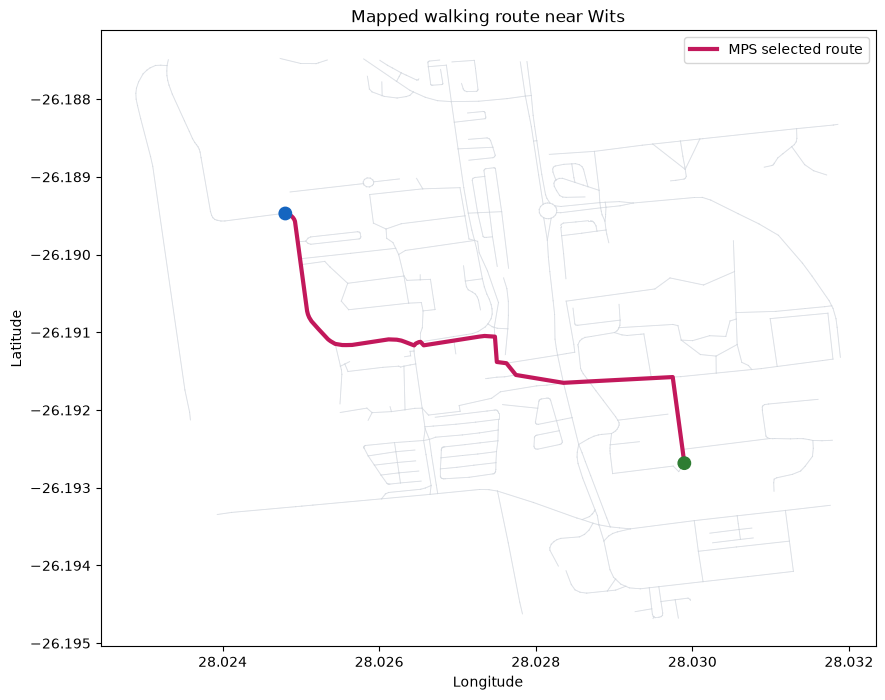

In [5]:
import matplotlib.pyplot as plt

if result is not None:
    xs = [float(graph.nodes[node]['x']) for node in route]
    ys = [float(graph.nodes[node]['y']) for node in route]
    margin = 0.002
    xmin, xmax = min(xs)-margin, max(xs)+margin
    ymin, ymax = min(ys)-margin, max(ys)+margin
    fig, ax = plt.subplots(figsize=(10, 8))
    for u, v in graph.edges():
        a, b = graph.nodes[u], graph.nodes[v]
        x1, y1 = float(a['x']), float(a['y'])
        x2, y2 = float(b['x']), float(b['y'])
        if xmin <= x1 <= xmax and ymin <= y1 <= ymax and xmin <= x2 <= xmax and ymin <= y2 <= ymax:
            ax.plot([x1, x2], [y1, y2], color='#d3d8df', lw=0.6, alpha=0.55)
    ax.plot(xs, ys, color='#c2185b', lw=3, label='MPS selected route')
    ax.scatter([xs[0], xs[-1]], [ys[0], ys[-1]], c=['#2e7d32', '#1565c0'], s=80, zorder=3)
    ax.set(xlabel='Longitude', ylabel='Latitude', title='Mapped walking route near Wits')
    ax.legend()
    plt.show()


## Limits and next data step

OSM lighting and sidewalk tags are very sparse here. A route can satisfy the numerical limit while passing through streets whose lighting is unknown. Before public safety use, add verified lamp, sidewalk, crossing, construction, and time-of-day data and validate the score with local people. This prototype does **not** estimate GBV incidence or guarantee safety.

Tensor networks avoid needing a quantum computer, but runtime and accuracy still depend on corridor size, MPO complexity, and chosen bond dimension. This demo makes no claim that DMRG beats a classical constrained-route solver.
